# Olist Database - Delivery Time Prediction

**Author:** Alejandro Mezio


## 8.&nbsp;Prediction model

### Libraries

In [1]:
import os
import json
from pathlib import Path

import numpy as np
import pandas as pd
from scipy.stats import randint, uniform, loguniform

import seaborn as sns
import matplotlib.pyplot as plt
%matplotlib inline

In [2]:
# Preprocessing tools and metrics
from sklearn.model_selection import train_test_split, GridSearchCV
from sklearn.model_selection import RandomizedSearchCV # Alternative to GridSearchCV
from sklearn.preprocessing import StandardScaler, OneHotEncoder, PolynomialFeatures
from sklearn.metrics import mean_absolute_error, mean_squared_error, root_mean_squared_error, accuracy_score, make_scorer

# Tools to build pipelines
from sklearn.pipeline import Pipeline
from sklearn.compose import ColumnTransformer

# Machine Learning models
from sklearn.linear_model import LinearRegression, Ridge, Lasso, SGDRegressor
from sklearn.tree import DecisionTreeRegressor
from sklearn.ensemble import RandomForestRegressor
from xgboost import XGBRegressor
from xgboost import plot_importance as xgb_plot_importance
from sklearn.svm import LinearSVR # SVR

# To save already-trained models
import pickle

In [3]:
pd.options.mode.copy_on_write = True
pd.options.mode.chained_assignment = 'raise'

In [4]:
# "models" folder where we save the trained models
models_path = './models'
os.makedirs(models_path, exist_ok=True)

---

### Loading data

In [5]:
# Function to load the dataframes together with their datatype dictionaries
def load_dataframe(base_path, name):
    dtype_path = Path(base_path) / f"{name}_datatypes.txt"
    csv_path = Path(base_path) / f"{name}.csv"
    
    with open(dtype_path, "r") as file:
        datatypes = json.load(file)

    # Extract the date columns
    datetime_cols = [col for col, dtype in datatypes.items() if dtype == 'datetime64[ns]']
    for col in datetime_cols:
        del datatypes[col]

    return pd.read_csv(csv_path, dtype=datatypes, parse_dates=datetime_cols)

In [6]:
base = "./data/processed"
name = "orders_final"
df_final = load_dataframe(base, name)

In [7]:
df_final.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 90137 entries, 0 to 90136
Data columns (total 46 columns):
 #   Column                         Non-Null Count  Dtype         
---  ------                         --------------  -----         
 0   order_purchase_timestamp       90137 non-null  datetime64[ns]
 1   order_approved_at              90137 non-null  datetime64[ns]
 2   order_delivered_carrier_date   90137 non-null  datetime64[ns]
 3   order_delivered_customer_date  90137 non-null  datetime64[ns]
 4   order_estimated_delivery_date  90137 non-null  datetime64[ns]
 5   order_purchase_year            90137 non-null  int64         
 6   order_purchase_month           90137 non-null  int64         
 7   order_purchase_dayofmonth      90137 non-null  int64         
 8   order_purchase_dayofweek       90137 non-null  int64         
 9   order_purchase_year_month      90137 non-null  object        
 10  order_purchase_year_month_day  90137 non-null  object        
 11  order_purchase_

---

### Feature selection

We split the columns into numerical and categorical, to apply different preprocessing to each.

Clarification about the target-related quantities:

- `days_to_delivered` is the **target**, the `y` variable. It counts the days elapsed between the purchase and the order reaching the buyer.
- `days_estimated` is the estimate made by Olist's "old" model, which we aim to improve.
- `days_predicted` is the name we will give to our model's prediction, the "new" model. It is the `y_hat` variable.
- `days_base_model` is the estimate of the base model (linear regression without regularization) against which we intend to compare the metric of the models under evaluation.

The old model `days_estimated` can be thought of as a natural starting point, but it is also a model that overestimates the target (sometimes grossly) and would not allow a representative comparison of the predictive power of the new models. After all, the discrepancy of this "old" model with the target is what motivates the goal of this project.

Features used:
- `distance_km`
- `price`
- `freight_value`
- `product_chargeable_weight`
- `sales_same_state`
- `product_sales_volume`
- `route`

Other possible ones:
- `total_value`
- `product_segment`

In [8]:
numerical_features = ['price', 'freight_value', 'product_chargeable_weight', 'distance_km','sales_same_state'] # 'total_value',
categorical_features = ['product_sales_volume', 'route'] # 'product_segment'
target_columns = ['days_to_delivered', 'days_estimated']

X = df_final[numerical_features + categorical_features]
y = df_final[target_columns]

---

### Preprocessing

In [9]:
numerical_transformer = Pipeline(steps=[
    ('scaler', StandardScaler())
])

categorical_transformer = Pipeline(steps=[
        ('onehot', OneHotEncoder(handle_unknown='ignore'))
])

To use `drop='first'` in OneHotEncoder or not?

With k categories, this routine will create k new binary columns. If we include all of them in the model, there will be perfect multicollinearity. The `drop='first'` option removes one of those columns, leaving k-1 linearly independent columns.

But using this option can also bring some drawbacks. Reading about the topic, we highlight these two:

- **Interpretability:** Omitting a column implies that the coefficients of the remaining columns are interpreted relative to the removed category. While this approach can be valid, it makes interpreting the results harder, especially if the first category is not a natural baseline.

- **Regularized models:** If we use regularized linear models (e.g. Ridge, Lasso), multicollinearity is usually a minor problem, since regularization techniques can handle it. In such cases, removing a column might not offer significant benefits, and could even introduce bias.

For the moment we will not use `drop='first'`.

In [10]:
preprocessor = ColumnTransformer(
    transformers=[
        ('num', numerical_transformer, numerical_features),
        ('cat', categorical_transformer, categorical_features)
    ]
)

### Train/test split

In [11]:
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=888)

To evaluate whether the train/test split of the target (`days_to_delivered`) is unbiased, which could otherwise cause some data leakage problem, we plot the target distribution in both datasets and compare.

There could also be a kind of imbalance in the target (recall it is a continuous variable).

We also plot `days_estimated`, the values produced by the "old" estimator.

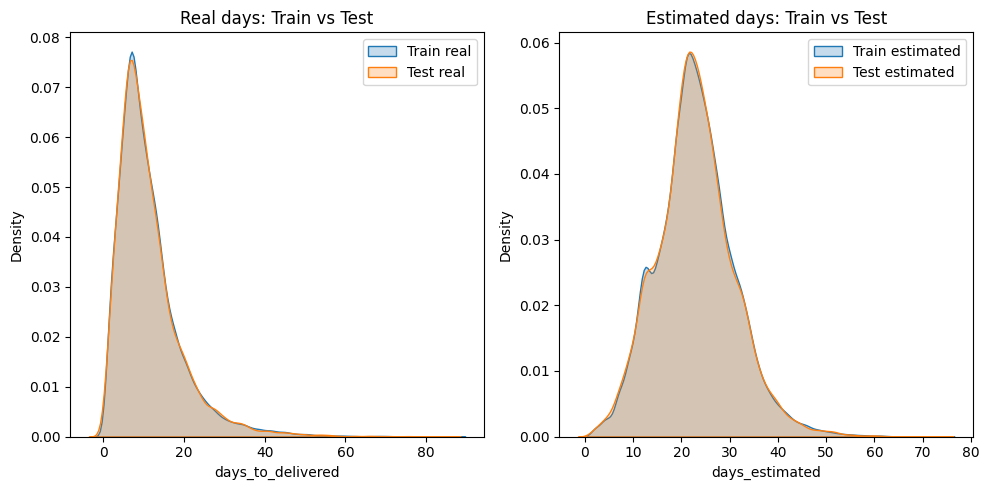

In [12]:
fig, axes = plt.subplots(1, 2, figsize=(10, 5))
sns.kdeplot(y_train['days_to_delivered'], ax=axes[0], label='Train real', fill=True)
sns.kdeplot(y_test['days_to_delivered'], ax=axes[0], label='Test real', fill=True)
axes[0].legend() ; axes[0].set_title('Real days: Train vs Test')

sns.kdeplot(y_train['days_estimated'], ax=axes[1], label='Train estimated', fill=True)
sns.kdeplot(y_test['days_estimated'], ax=axes[1], label='Test estimated', fill=True)
axes[1].legend() ; axes[1].set_title('Estimated days: Train vs Test')
plt.tight_layout() ; plt.show()

Both distributions are very similar and, considering the left one, we will have no target imbalance problem.

### Metrics


We build a scoring function that computes MAE and RMSE:

In [13]:
scoring = {
    'mae': 'neg_mean_absolute_error',
    'rmse': 'neg_root_mean_squared_error',
    }

We review what is written in the following article: [Which scoring function should I use?](https://scikit-learn.org/stable/modules/model_evaluation.html#which-scoring-function)

- MSE: The mean squared error (or its square root) penalizes larger errors more, being more sensitive to outliers. Its interpretation is not as direct.

- MAE: The mean absolute error is more robust and less sensitive to outlier values. Its interpretation is more direct, since it is the average of the errors.


We will therefore use MAE as the metric for training the models; we gain interpretability, even though we do not amplify the largest errors.

On the other hand, recall that MAE is not as mathematically smooth and we might run into trouble when optimizing.

### Models: Building pipelines and hyperparameter grids

We will use several regression models:

0) Simple Linear Regression (this will be our base model for comparison)
1) Linear Regression with L1 regularization (Lasso)
2) Linear Regression with L2 regularization (Ridge)
3) Ridge Regression with degree-2 polynomial features
4) Decision Tree
5) Random Forest
6) eXtreme Gradient Boosting (XGBoost)
7) Support Vector Machine (SVM) Regressor
8) Stochastic Gradient Descent (SGD)

**NOTE:** In this version we added 3 new models (xgb, svm and sgd) that were not in the original final presentation (and are therefore not reflected in the course report, which remains in the original course repository).

#### 0. Base model: Linear Regression

As a starting point we will use a simple linear regression without regularization as the base model

In [14]:
linreg_model = Pipeline(steps=[
    ('preprocessor', preprocessor),
    ('linreg', LinearRegression())
])

parameters_linreg ={}

grid_search_linreg = GridSearchCV(linreg_model, parameters_linreg,
                                  scoring=scoring, refit='mae',
                                  cv=5, n_jobs=-1)

#### 1. Lasso (L1)

This model can help us evaluate whether any of the features is superfluous.

In [15]:
lasso_model = Pipeline(steps=[
    ('preprocessor', preprocessor),
    ('lasso', Lasso(random_state=888))
])

parameters_lasso ={'lasso__alpha': [0.000001,
                                    0.00001,
                                    0.0001,
                                    0.001, 0.004, 0.005, 0.006,
                                    0.01, 0.015, 0.02,
                                    0.1,
                                    1.,
                                    10]}

grid_search_lasso = GridSearchCV(lasso_model, parameters_lasso,
                                 scoring=scoring, refit='mae',
                                 cv=5, n_jobs=-1)

#### 2. Ridge (L2)

In [16]:
ridge_model = Pipeline(steps=[
    ('preprocessor', preprocessor),
    ('ridge', Ridge(random_state=888))
])

parameters_ridge ={'ridge__alpha': [0.001,
                                    0.01,
                                    0.1,
                                    1,
                                    10, 50,
                                    100, 150, 200, 250, 300, 500,
                                    1000,
                                    10000]}

grid_search_ridge = GridSearchCV(ridge_model, parameters_ridge,
                                 scoring=scoring, refit='mae',
                                 cv=5, n_jobs=-1)

#### 3. Ridge + degree-2 polynomial features

In [17]:
polinomial_model = Pipeline(steps=[
    ('preprocessor', preprocessor),
    ('poly', PolynomialFeatures(degree=2)),
    ('ridge', Ridge(random_state=888))
])

parameters_poly ={'ridge__alpha': [0.01,
                                   0.1,
                                   1, 5, 6, 7, 8, 9,
                                   10, 12, 15, 20, 50,
                                   100,
                                   1000,
                                   10000]}

grid_search_poly = GridSearchCV(polinomial_model, parameters_poly, scoring=scoring, refit='mae', cv=5, n_jobs=-1)

#### 4. Decision Tree

In [18]:
tree_model = Pipeline(steps=[
    ('preprocessor', preprocessor),
    ('tree', DecisionTreeRegressor(random_state=888))
])

parameters_tree = {'tree__max_depth': [5, 7, 10, 15, 20],
                   'tree__max_features': ['sqrt', None],
                   'tree__min_samples_split': [2, 3, 5, 8],
                   'tree__min_samples_leaf': [50, 100, 200, 300, 400, 500],
                   }

grid_search_tree = GridSearchCV(tree_model, parameters_tree, scoring=scoring, refit='mae', cv=5, n_jobs=-1)

#### 5. Random forest

Since GridSearchCV is very time-consuming when training a Random Forest model, we opted for an optimized version: RandomizedSearchCV

In [19]:
forest_model = Pipeline(steps=[
    ('preprocessor', preprocessor),
    ('forest', RandomForestRegressor(random_state=888))
])

param_distributions_forest = {
    'forest__n_estimators': randint(100, 1000),
    'forest__max_depth': randint(5, 50),
    'forest__max_features': ['sqrt', 'log2'],
    'forest__min_samples_split': randint(2, 20),
    'forest__min_samples_leaf': randint(1, 10) }

randomized_search_forest = RandomizedSearchCV(forest_model, param_distributions_forest,
                                              scoring=scoring, refit='mae', n_iter=50,
                                              cv=5, n_jobs=-1, verbose=3, random_state=888)

Clarification about this type of cross-validation: `The search is non-exhaustive but often finds near-optimal results much faster than grid search`

#### 6. XGBoost

In [20]:
xgb_model = Pipeline(steps=[
    ('preprocessor', preprocessor),
    ('xgb', XGBRegressor(
        objective='reg:absoluteerror',  #   squarederror  pseudohubererror
        eval_metric='mae',
        random_state=888,
        tree_method='hist'  # often faster; replace with 'auto' if needed
    ))
])

param_distributions_xgb = {
    'xgb__n_estimators': randint(500, 1500),
    'xgb__max_depth': randint(3, 10),
    'xgb__learning_rate': uniform(0.005, 0.055),
    'xgb__subsample': uniform(0.5, 1.0),
    'xgb__colsample_bytree': uniform(0.5, 1.0),
    'xgb__min_child_weight': randint(5, 20),
    'xgb__gamma': uniform(0.0, 1.0),              # Lower gamma: MAE benefits from more flexible splits
    'xgb__reg_alpha': uniform(0.0, 2.0),          # L1
    'xgb__reg_lambda': uniform(0.5, 2.0),         # L2
    'xgb__gamma': uniform(0.0, 1.0)               # Smooth split penalty
}

randomized_search_xgb = RandomizedSearchCV(xgb_model, param_distributions_xgb,
                                           scoring=scoring, refit='mae', n_iter=50, 
                                           cv=5, n_jobs=-1, verbose=3, random_state=888)

#### 7. SVM Regressor (LinearSVR)

In [21]:
linear_svr_model = Pipeline(steps=[
    ('preprocessor', preprocessor),
    ('svr', LinearSVR(
        loss='epsilon_insensitive',
        epsilon=0,
        random_state=888
    ))
])

param_distributions_linear_svr = {
    'svr__C': loguniform(1e-3, 1e2),
    'svr__epsilon': uniform(0.0, 1.0),  # 0.00 – 1.00
    'svr__max_iter': [5000, 10000, 20000],
    'svr__tol': loguniform(1e-5, 1e-2)
}

randomized_search_linear_svr = RandomizedSearchCV(linear_svr_model, param_distributions_linear_svr,
                                                  scoring=scoring, refit='mae', n_iter=40,   # fewer needed because search space is small
                                                  cv=5, n_jobs=-1, verbose=3, random_state=888)

#### 8. SGD Regressor

In [22]:
sgd_model = Pipeline(steps=[
    ('preprocessor', preprocessor),
    ('sgd', SGDRegressor(
        loss='epsilon_insensitive',  # SVR-like loss
        epsilon=0,
        random_state=888,
        penalty='elasticnet',        # elastic net works well in high dimensions
        max_iter=5000,
        tol=1e-3
    ))
])

param_distributions_sgd = {
    'sgd__alpha': loguniform(1e-6, 1e-2),         # regularization strength
    'sgd__l1_ratio': uniform(0.0, 1.0),           # elastic net mixing
    'sgd__epsilon': uniform(0.0, 1.0),
    'sgd__eta0': loguniform(1e-4, 1e-1),          # initial learning rate
    'sgd__learning_rate': ['optimal', 'invscaling', 'adaptive'],
    'sgd__max_iter': [2000, 5000, 10000],
    'sgd__tol': loguniform(1e-5, 1e-2)
}

randomized_search_sgd = RandomizedSearchCV(sgd_model, param_distributions_sgd,
                                           scoring=scoring, refit='mae', n_iter=50,
                                           cv=5, n_jobs=-1, verbose=3, random_state=888)

### Models: Training

Each model below is **fitted or loaded**: if its pickle exists in the `models/` folder it is loaded (skipping re-training), otherwise it is fitted and saved. A full first run from a fresh clone re-trains all 9 searches and can take a few hours; subsequent runs are fast.

**Note:** hyperparameter searches re-run with newer library versions can produce slightly different winners and scores; if that happens, the numbers quoted in the README must be refreshed from the new outputs.

All stochastic components are seeded (`random_state=888`, including the randomized searches), so a full re-run reproduces the same winners. Exception: XGBoost's `hist` tree method with multithreading can show tiny run-to-run jitter (~0.001-0.01 days of MAE), which is harmless and expected.

#### <u>0. Base model</u>


In [23]:
model_name = 'linreg_model.pkl'
linreg_path = os.path.join(models_path, model_name)

if os.path.exists(linreg_path):
    # Load the previously fitted search (skips re-training)
    with open(linreg_path, 'rb') as model_file:
        grid_search_linreg = pickle.load(model_file)
else:
    # First run (fresh clone): fit and persist
    grid_search_linreg.fit(X_train, y_train['days_to_delivered'])
    with open(linreg_path, 'wb') as model_file:
        pickle.dump(grid_search_linreg, model_file)

In [24]:
grid_search_linreg.cv_results_.keys()

dict_keys(['mean_fit_time', 'std_fit_time', 'mean_score_time', 'std_score_time', 'params', 'split0_test_mae', 'split1_test_mae', 'split2_test_mae', 'split3_test_mae', 'split4_test_mae', 'mean_test_mae', 'std_test_mae', 'rank_test_mae', 'split0_test_rmse', 'split1_test_rmse', 'split2_test_rmse', 'split3_test_rmse', 'split4_test_rmse', 'mean_test_rmse', 'std_test_rmse', 'rank_test_rmse'])

In [25]:
results_linreg = pd.DataFrame(grid_search_linreg.cv_results_)
results_linreg[['mean_test_mae', 'std_test_mae', 'mean_test_rmse', 'std_test_rmse']]

,mean_test_mae,std_test_mae,mean_test_rmse,std_test_rmse
0,-4.824247,0.034458,-7.14798,0.110177


In [26]:
results_linreg[['split0_test_mae', 'split1_test_mae', 'split2_test_mae', 'split3_test_mae', 'split4_test_mae']]

,split0_test_mae,split1_test_mae,split2_test_mae,split3_test_mae,split4_test_mae
0,-4.877353,-4.797503,-4.778271,-4.827151,-4.840958


We save the base predictions into the 'days_base_model' variable:

In [27]:
y_train['days_base_model'] = grid_search_linreg.predict(X_train)
y_test['days_base_model'] = grid_search_linreg.predict(X_test)

---

#### <u>1. Lasso</u>

In [28]:
model_name = 'lasso_model.pkl'
lasso_path = os.path.join(models_path, model_name)

if os.path.exists(lasso_path):
    # Load the previously fitted search (skips re-training)
    with open(lasso_path, 'rb') as model_file:
        grid_search_lasso = pickle.load(model_file)
else:
    # First run (fresh clone): fit and persist
    grid_search_lasso.fit(X_train, y_train['days_to_delivered'])
    with open(lasso_path, 'wb') as model_file:
        pickle.dump(grid_search_lasso, model_file)

In [29]:
print("Best alpha:", grid_search_lasso.best_params_['lasso__alpha'])
print("Best MAE (CV):", -grid_search_lasso.best_score_)

Best alpha: 0.006
Best MAE (CV): 4.82355934123936


In [30]:
results_lasso = pd.DataFrame(grid_search_lasso.cv_results_)
results_lasso[['param_lasso__alpha',
               'mean_test_mae', 'std_test_mae',
               'mean_test_rmse', 'std_test_rmse'
               ]].sort_values(by='mean_test_mae', ascending=False).head(5)

,param_lasso__alpha,mean_test_mae,std_test_mae,mean_test_rmse,std_test_rmse
6,0.006,-4.823559,0.035101,-7.148519,0.110613
5,0.005,-4.823603,0.034977,-7.148354,0.110558
7,0.010,-4.823638,0.035572,-7.149468,0.110826
4,0.004,-4.823676,0.034849,-7.148211,0.110484
3,0.001,-4.824061,0.034539,-7.147983,0.110239


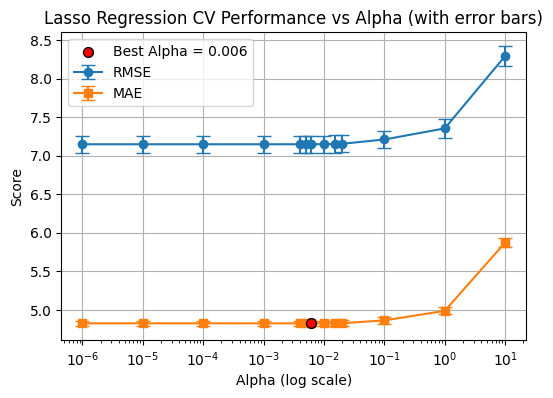

In [31]:
# Extract alphas, mean scores, std deviations
alphas = results_lasso['param_lasso__alpha'].astype(float)
mean_rmse = results_lasso['mean_test_rmse']; mean_mae = results_lasso['mean_test_mae']
std_rmse = results_lasso['std_test_rmse']; std_mae = results_lasso['std_test_mae']
# Using neg_* scorers, flip signs back
mean_rmse, std_rmse = -mean_rmse, std_rmse ; mean_mae, std_mae = -mean_mae, std_mae

# Get best alpha from grid search
best_alpha = grid_search_lasso.best_params_['lasso__alpha']
best_mae   = mean_mae[results_lasso['param_lasso__alpha'] == best_alpha].values[0]

plt.figure(figsize=(6,4))

plt.errorbar(alphas, mean_rmse, yerr=std_rmse, fmt='-o', capsize=5, label='RMSE')
plt.errorbar(alphas, mean_mae, yerr=std_mae, fmt='-s', capsize=5, label='MAE')

# Highlight best alpha point
plt.scatter(best_alpha, best_mae, color='red', s=50, edgecolor='black',
            zorder=5, label=f'Best Alpha = {best_alpha}')

plt.xscale('log'); plt.xlabel("Alpha (log scale)"); plt.ylabel("Score")
plt.title("Lasso Regression CV Performance vs Alpha (with error bars)")
plt.legend(); plt.grid(True); plt.show()

---

#### <u>2. Ridge</u>

In [32]:
model_name = 'ridge_model.pkl'
ridge_path = os.path.join(models_path, model_name)

if os.path.exists(ridge_path):
    # Load the previously fitted search (skips re-training)
    with open(ridge_path, 'rb') as model_file:
        grid_search_ridge = pickle.load(model_file)
else:
    # First run (fresh clone): fit and persist
    grid_search_ridge.fit(X_train, y_train['days_to_delivered'])
    with open(ridge_path, 'wb') as model_file:
        pickle.dump(grid_search_ridge, model_file)

In [33]:
print("Best alpha:", grid_search_ridge.best_params_['ridge__alpha'])
print("Best MAE (CV):", -grid_search_ridge.best_score_)

Best alpha: 300
Best MAE (CV): 4.823270626741262


In [34]:
results_ridge = pd.DataFrame(grid_search_ridge.cv_results_)
results_ridge[['param_ridge__alpha',
               'mean_test_mae', 'std_test_mae',
               'mean_test_rmse', 'std_test_rmse'
               ]].sort_values(by='mean_test_mae', ascending=False).head(5)

,param_ridge__alpha,mean_test_mae,std_test_mae,mean_test_rmse,std_test_rmse
10,300.0,-4.823271,0.035203,-7.149247,0.110764
9,250.0,-4.823286,0.035087,-7.148888,0.110679
8,200.0,-4.823345,0.034964,-7.148575,0.110589
7,150.0,-4.823460,0.034837,-7.148315,0.110495
11,500.0,-4.823554,0.035655,-7.151004,0.111070


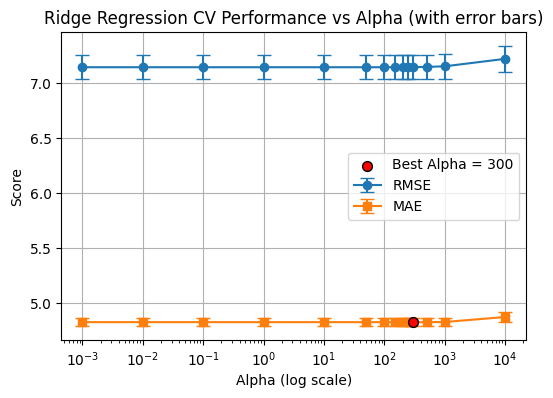

In [35]:
# Extract alphas, mean scores, std deviations
alphas = results_ridge['param_ridge__alpha'].astype(float)
mean_rmse = results_ridge['mean_test_rmse']; mean_mae = results_ridge['mean_test_mae']
std_rmse = results_ridge['std_test_rmse']; std_mae = results_ridge['std_test_mae']
# Using neg_* scorers, flip signs back
mean_rmse, std_rmse = -mean_rmse, std_rmse ; mean_mae, std_mae = -mean_mae, std_mae

# Get best alpha from grid search
best_alpha = grid_search_ridge.best_params_['ridge__alpha']
best_mae   = mean_mae[results_ridge['param_ridge__alpha'] == best_alpha].values[0]

plt.figure(figsize=(6,4))

plt.errorbar(alphas, mean_rmse, yerr=std_rmse, fmt='-o', capsize=5, label='RMSE')
plt.errorbar(alphas, mean_mae, yerr=std_mae, fmt='-s', capsize=5, label='MAE')

# Highlight best alpha point
plt.scatter(best_alpha, best_mae, color='red', s=50, edgecolor='black',
            zorder=5, label=f'Best Alpha = {best_alpha}')

plt.xscale('log') ; plt.xlabel("Alpha (log scale)") ; plt.ylabel("Score")
plt.title("Ridge Regression CV Performance vs Alpha (with error bars)")
plt.legend() ; plt.grid(True) ; plt.show()

---

#### <u>3. Ridge + Polynomials</u>


In [36]:
model_name = 'poly_model.pkl'
poly_path = os.path.join(models_path, model_name)

if os.path.exists(poly_path):
    # Load the previously fitted search (skips re-training)
    with open(poly_path, 'rb') as model_file:
        grid_search_poly = pickle.load(model_file)
else:
    # First run (fresh clone): fit and persist
    grid_search_poly.fit(X_train, y_train['days_to_delivered'])
    with open(poly_path, 'wb') as model_file:
        pickle.dump(grid_search_poly, model_file)

In [37]:
print("Best alpha:", grid_search_poly.best_params_['ridge__alpha'])
print("Best MAE (CV):", -grid_search_poly.best_score_)

Best alpha: 7
Best MAE (CV): 4.780823987283601


In [38]:
results_poly = pd.DataFrame(grid_search_poly.cv_results_)
results_poly[['param_ridge__alpha',
              'mean_test_mae', 'std_test_mae',
              'mean_test_rmse', 'std_test_rmse'
              ]].sort_values(by='mean_test_mae', ascending=False).head(5)

,param_ridge__alpha,mean_test_mae,std_test_mae,mean_test_rmse,std_test_rmse
5,7.0,-4.780824,0.033468,-7.116747,0.106341
6,8.0,-4.780825,0.033461,-7.116739,0.106346
4,6.0,-4.780825,0.033476,-7.116756,0.106335
7,9.0,-4.780827,0.033454,-7.116733,0.106351
3,5.0,-4.780828,0.033485,-7.116767,0.106330


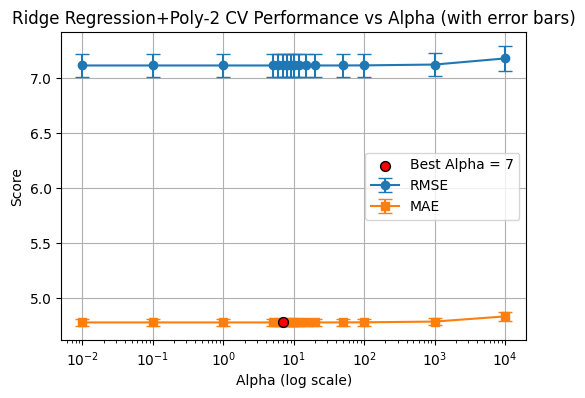

In [39]:
# Extract alphas, mean scores, std deviations
alphas = results_poly['param_ridge__alpha'].astype(float)
mean_rmse = results_poly['mean_test_rmse'] ; mean_mae = results_poly['mean_test_mae']
std_rmse = results_poly['std_test_rmse'] ; std_mae = results_poly['std_test_mae']
# Using neg_* scorers, flip signs back
mean_rmse, std_rmse = -mean_rmse, std_rmse ; mean_mae, std_mae = -mean_mae, std_mae

# Get best alpha from grid search
best_alpha = grid_search_poly.best_params_['ridge__alpha']
best_mae   = mean_mae[results_poly['param_ridge__alpha'] == best_alpha].values[0]

plt.figure(figsize=(6,4))

plt.errorbar(alphas, mean_rmse, yerr=std_rmse, fmt='-o', capsize=5, label='RMSE')
plt.errorbar(alphas, mean_mae, yerr=std_mae, fmt='-s', capsize=5, label='MAE')

# Highlight best alpha point
plt.scatter(best_alpha, best_mae, color='red', s=50, edgecolor='black',
            zorder=5, label=f'Best Alpha = {best_alpha}')

plt.xscale('log') ; plt.xlabel("Alpha (log scale)") ; plt.ylabel("Score")
plt.title("Ridge Regression+Poly-2 CV Performance vs Alpha (with error bars)")
plt.legend() ; plt.grid(True) ; plt.show()

---

#### <u>4. Decision Tree</u>

In [40]:
model_name = 'tree_model.pkl'
tree_path = os.path.join(models_path, model_name)

if os.path.exists(tree_path):
    # Load the previously fitted search (skips re-training)
    with open(tree_path, 'rb') as model_file:
        grid_search_tree = pickle.load(model_file)
else:
    # First run (fresh clone): fit and persist
    grid_search_tree.fit(X_train, y_train['days_to_delivered'])
    with open(tree_path, 'wb') as model_file:
        pickle.dump(grid_search_tree, model_file)

In [41]:
print("Best max_depth:", grid_search_tree.best_params_['tree__max_depth'])
print("Best max_features:", grid_search_tree.best_params_['tree__max_features'])
print("Best min_samples_leaf:", grid_search_tree.best_params_['tree__min_samples_leaf'])
print("Best min_samples_split:", grid_search_tree.best_params_['tree__min_samples_split'])
print("Best MAE (CV):", -grid_search_tree.best_score_)

Best max_depth: 10
Best max_features: None
Best min_samples_leaf: 200
Best min_samples_split: 2
Best MAE (CV): 4.756191301861419


In [42]:
results_tree = pd.DataFrame(grid_search_tree.cv_results_)
results_tree[['param_tree__max_depth',
              'param_tree__max_features',
              'param_tree__min_samples_leaf',
              'param_tree__min_samples_split',
              'mean_test_mae', 'std_test_mae',
              'mean_test_rmse', 'std_test_rmse']].sort_values(by='mean_test_mae', ascending=False).head(5)

,param_tree__max_depth,param_tree__max_features,param_tree__min_samples_leaf,param_tree__min_samples_split,mean_test_mae,std_test_mae,mean_test_rmse,std_test_rmse
128,10,None,200,2,-4.756191,0.038412,-7.105776,0.103474
129,10,None,200,3,-4.756191,0.038412,-7.105776,0.103474
130,10,None,200,5,-4.756191,0.038412,-7.105776,0.103474
131,10,None,200,8,-4.756191,0.038412,-7.105776,0.103474
132,10,None,300,2,-4.756893,0.035135,-7.103103,0.106709


In [43]:
grid_search_tree.cv_results_.keys()

dict_keys(['mean_fit_time', 'std_fit_time', 'mean_score_time', 'std_score_time', 'param_tree__max_depth', 'param_tree__max_features', 'param_tree__min_samples_leaf', 'param_tree__min_samples_split', 'params', 'split0_test_mae', 'split1_test_mae', 'split2_test_mae', 'split3_test_mae', 'split4_test_mae', 'mean_test_mae', 'std_test_mae', 'rank_test_mae', 'split0_test_rmse', 'split1_test_rmse', 'split2_test_rmse', 'split3_test_rmse', 'split4_test_rmse', 'mean_test_rmse', 'std_test_rmse', 'rank_test_rmse'])

In [44]:
results_tree[['split0_test_mae',
              'split1_test_mae',
              'split2_test_mae',
              'split3_test_mae',
              'split4_test_mae',
              'mean_test_mae', 'std_test_mae'
              ]].sort_values(by='mean_test_mae', ascending=False).head(5)

,split0_test_mae,split1_test_mae,split2_test_mae,split3_test_mae,split4_test_mae,mean_test_mae,std_test_mae
128,-4.824735,-4.718742,-4.721134,-4.753714,-4.762632,-4.756191,0.038412
129,-4.824735,-4.718742,-4.721134,-4.753714,-4.762632,-4.756191,0.038412
130,-4.824735,-4.718742,-4.721134,-4.753714,-4.762632,-4.756191,0.038412
131,-4.824735,-4.718742,-4.721134,-4.753714,-4.762632,-4.756191,0.038412
132,-4.814220,-4.727467,-4.714169,-4.757791,-4.770816,-4.756893,0.035135


---

#### <u>5. Random Forest</u>


In [45]:
model_name = 'forest_randomized_model.pkl'
forest_randomized_path = os.path.join(models_path, model_name)

if os.path.exists(forest_randomized_path):
    # Load the previously fitted search (skips re-training)
    with open(forest_randomized_path, 'rb') as model_file:
        randomized_search_forest = pickle.load(model_file)
else:
    # First run (fresh clone): fit and persist
    randomized_search_forest.fit(X_train, y_train['days_to_delivered'])
    with open(forest_randomized_path, 'wb') as model_file:
        pickle.dump(randomized_search_forest, model_file)

Fitting 5 folds for each of 50 candidates, totalling 250 fits


In [46]:
print("Best max_depth:", randomized_search_forest.best_params_['forest__max_depth'])
print("Best max_features:", randomized_search_forest.best_params_['forest__max_features'])
print("Best min_samples_leaf:", randomized_search_forest.best_params_['forest__min_samples_leaf'])
print("Best min_samples_split:", randomized_search_forest.best_params_['forest__min_samples_split'])
print("Best n_estimators:", randomized_search_forest.best_params_['forest__n_estimators'])
print("Best MAE (CV):", -randomized_search_forest.best_score_)

Best max_depth: 47
Best max_features: log2
Best min_samples_leaf: 7
Best min_samples_split: 9
Best n_estimators: 896
Best MAE (CV): 4.649276643574732


In [47]:
randomized_search_forest.cv_results_.keys()

dict_keys(['mean_fit_time', 'std_fit_time', 'mean_score_time', 'std_score_time', 'param_forest__max_depth', 'param_forest__max_features', 'param_forest__min_samples_leaf', 'param_forest__min_samples_split', 'param_forest__n_estimators', 'params', 'split0_test_mae', 'split1_test_mae', 'split2_test_mae', 'split3_test_mae', 'split4_test_mae', 'mean_test_mae', 'std_test_mae', 'rank_test_mae', 'split0_test_rmse', 'split1_test_rmse', 'split2_test_rmse', 'split3_test_rmse', 'split4_test_rmse', 'mean_test_rmse', 'std_test_rmse', 'rank_test_rmse'])

In [48]:
results_forest_randomized = pd.DataFrame(randomized_search_forest.cv_results_)
results_forest_randomized[['param_forest__max_depth',
                           'param_forest__max_features',
                           'param_forest__min_samples_leaf',
                           'param_forest__min_samples_split',
                           'param_forest__n_estimators',
                           'mean_test_mae', 'std_test_mae',
                           'mean_test_rmse', 'std_test_rmse'
                           ]].sort_values(by='mean_test_mae', ascending=False).head(5)

,param_forest__max_depth,param_forest__max_features,param_forest__min_samples_leaf,param_forest__min_samples_split,param_forest__n_estimators,mean_test_mae,std_test_mae,mean_test_rmse,std_test_rmse
30,47,log2,7,9,896,-4.649277,0.034345,-6.985231,0.107608
22,35,sqrt,7,12,935,-4.649299,0.034329,-6.985230,0.107611
28,42,sqrt,7,8,747,-4.649593,0.034188,-6.985393,0.107691
2,48,log2,7,12,587,-4.649658,0.034582,-6.985358,0.107913
21,46,log2,7,4,515,-4.650056,0.034481,-6.985724,0.107513


In [49]:
results_forest_randomized[['split0_test_mae',
                           'split1_test_mae',
                           'split2_test_mae',
                           'split3_test_mae',
                           'split4_test_mae',
                           'mean_test_mae', 'std_test_mae'
                           ]].sort_values(by='mean_test_mae', ascending=False).head(5)

,split0_test_mae,split1_test_mae,split2_test_mae,split3_test_mae,split4_test_mae,mean_test_mae,std_test_mae
30,-4.711411,-4.621533,-4.613717,-4.650917,-4.648806,-4.649277,0.034345
22,-4.710793,-4.620704,-4.613408,-4.651329,-4.650261,-4.649299,0.034329
28,-4.711195,-4.621655,-4.614010,-4.651168,-4.649936,-4.649593,0.034188
2,-4.712149,-4.621155,-4.614154,-4.650876,-4.649954,-4.649658,0.034582
21,-4.712444,-4.621424,-4.614966,-4.651094,-4.650353,-4.650056,0.034481


---

#### <u>6. XGBoost</u>


In [50]:
model_name = 'xgb_randomized_model.pkl'
xgb_randomized_path = os.path.join(models_path, model_name)

if os.path.exists(xgb_randomized_path):
    # Load the previously fitted search (skips re-training)
    with open(xgb_randomized_path, 'rb') as model_file:
        randomized_search_xgb = pickle.load(model_file)
else:
    # First run (fresh clone): fit and persist
    randomized_search_xgb.fit(X_train, y_train['days_to_delivered'])
    with open(xgb_randomized_path, 'wb') as model_file:
        pickle.dump(randomized_search_xgb, model_file)

Fitting 5 folds for each of 50 candidates, totalling 250 fits


C:\Users\Ale\AppData\Local\Packages\PythonSoftwareFoundation.Python.3.11_qbz5n2kfra8p0\LocalCache\local-packages\Python311\site-packages\sklearn\model_selection\_validation.py:516: FitFailedWarning: 
160 fits failed out of a total of 250.
The score on these train-test partitions for these parameters will be set to nan.
If these failures are not expected, you can try to debug them by setting error_score='raise'.

Below are more details about the failures:
--------------------------------------------------------------------------------
5 fits failed with the following error:
Traceback (most recent call last):
  File "C:\Users\Ale\AppData\Local\Packages\PythonSoftwareFoundation.Python.3.11_qbz5n2kfra8p0\LocalCache\local-packages\Python311\site-packages\sklearn\model_selection\_validation.py", line 859, in _fit_and_score
    estimator.fit(X_train, y_train, **fit_params)
  File "C:\Users\Ale\AppData\Local\Packages\PythonSoftwareFoundation.Python.3.11_qbz5n2kfra8p0\LocalCache\local-packages\

In [51]:
randomized_search_xgb.cv_results_.keys()

dict_keys(['mean_fit_time', 'std_fit_time', 'mean_score_time', 'std_score_time', 'param_xgb__colsample_bytree', 'param_xgb__gamma', 'param_xgb__learning_rate', 'param_xgb__max_depth', 'param_xgb__min_child_weight', 'param_xgb__n_estimators', 'param_xgb__reg_alpha', 'param_xgb__reg_lambda', 'param_xgb__subsample', 'params', 'split0_test_mae', 'split1_test_mae', 'split2_test_mae', 'split3_test_mae', 'split4_test_mae', 'mean_test_mae', 'std_test_mae', 'rank_test_mae', 'split0_test_rmse', 'split1_test_rmse', 'split2_test_rmse', 'split3_test_rmse', 'split4_test_rmse', 'mean_test_rmse', 'std_test_rmse', 'rank_test_rmse'])

In [52]:
randomized_search_xgb.best_score_

np.float64(-4.4258448600769045)

In [53]:
print("Best colsample_bytree:", randomized_search_xgb.best_params_['xgb__colsample_bytree'])
print("Best gamma:           ", randomized_search_xgb.best_params_['xgb__gamma'])
print("Best learning_rate:   ", randomized_search_xgb.best_params_['xgb__learning_rate'])
print("Best max_depth:       ", randomized_search_xgb.best_params_['xgb__max_depth'])
print("Best min_child_weight:", randomized_search_xgb.best_params_['xgb__min_child_weight'])
print("Best n_estimators:    ", randomized_search_xgb.best_params_['xgb__n_estimators'])
print("Best reg_alpha:       ", randomized_search_xgb.best_params_['xgb__reg_alpha'])
print("Best reg_lambda:      ", randomized_search_xgb.best_params_['xgb__reg_lambda'])
print("Best subsample:       ", randomized_search_xgb.best_params_['xgb__subsample'])
print("Best MAE (CV):        ", -randomized_search_xgb.best_score_)

Best colsample_bytree: 0.5926346204785158
Best gamma:            0.3989055860680718
Best learning_rate:    0.03396859397632011
Best max_depth:        9
Best min_child_weight: 7
Best n_estimators:     1265
Best reg_alpha:        1.843916967734104
Best reg_lambda:       1.150521805221136
Best subsample:        0.8346693761980802
Best MAE (CV):         4.4258448600769045


---

#### <u>7. SVM Regressor</u>


In [54]:
model_name = 'svr_randomized_model.pkl'
svr_randomized_path = os.path.join(models_path, model_name)

if os.path.exists(svr_randomized_path):
    # Load the previously fitted search (skips re-training)
    with open(svr_randomized_path, 'rb') as model_file:
        randomized_search_linear_svr = pickle.load(model_file)
else:
    # First run (fresh clone): fit and persist
    randomized_search_linear_svr.fit(X_train, y_train['days_to_delivered'])
    with open(svr_randomized_path, 'wb') as model_file:
        pickle.dump(randomized_search_linear_svr, model_file)

Fitting 5 folds for each of 40 candidates, totalling 200 fits


In [55]:
randomized_search_linear_svr.cv_results_.keys()

dict_keys(['mean_fit_time', 'std_fit_time', 'mean_score_time', 'std_score_time', 'param_svr__C', 'param_svr__epsilon', 'param_svr__max_iter', 'param_svr__tol', 'params', 'split0_test_mae', 'split1_test_mae', 'split2_test_mae', 'split3_test_mae', 'split4_test_mae', 'mean_test_mae', 'std_test_mae', 'rank_test_mae', 'split0_test_rmse', 'split1_test_rmse', 'split2_test_rmse', 'split3_test_rmse', 'split4_test_rmse', 'mean_test_rmse', 'std_test_rmse', 'rank_test_rmse'])

In [56]:
print("Best C:        ", randomized_search_linear_svr.best_params_['svr__C'])
print("Best epsilon:  ", randomized_search_linear_svr.best_params_['svr__epsilon'])
print("Best max_iter: ", randomized_search_linear_svr.best_params_['svr__max_iter'])
print("Best tol:      ", randomized_search_linear_svr.best_params_['svr__tol'])
print("Best MAE (CV): ", -randomized_search_linear_svr.best_score_)

Best C:         13.333115508885085
Best epsilon:   0.7746624582967129
Best max_iter:  10000
Best tol:       0.00013020823388143165
Best MAE (CV):  4.632870030418749


---

#### <u>8. SGD Regressor</u>


In [57]:
model_name = 'sgd_randomized_model.pkl'
sgd_randomized_path = os.path.join(models_path, model_name)

if os.path.exists(sgd_randomized_path):
    # Load the previously fitted search (skips re-training)
    with open(sgd_randomized_path, 'rb') as model_file:
        randomized_search_sgd = pickle.load(model_file)
else:
    # First run (fresh clone): fit and persist
    randomized_search_sgd.fit(X_train, y_train['days_to_delivered'])
    with open(sgd_randomized_path, 'wb') as model_file:
        pickle.dump(randomized_search_sgd, model_file)

Fitting 5 folds for each of 50 candidates, totalling 250 fits


In [58]:
randomized_search_sgd.cv_results_.keys()

dict_keys(['mean_fit_time', 'std_fit_time', 'mean_score_time', 'std_score_time', 'param_sgd__alpha', 'param_sgd__epsilon', 'param_sgd__eta0', 'param_sgd__l1_ratio', 'param_sgd__learning_rate', 'param_sgd__max_iter', 'param_sgd__tol', 'params', 'split0_test_mae', 'split1_test_mae', 'split2_test_mae', 'split3_test_mae', 'split4_test_mae', 'mean_test_mae', 'std_test_mae', 'rank_test_mae', 'split0_test_rmse', 'split1_test_rmse', 'split2_test_rmse', 'split3_test_rmse', 'split4_test_rmse', 'mean_test_rmse', 'std_test_rmse', 'rank_test_rmse'])

In [59]:
print("Best alpha:        ", randomized_search_sgd.best_params_['sgd__alpha'])
print("Best epsilon:  ", randomized_search_sgd.best_params_['sgd__epsilon'])
print("Best eta0:        ", randomized_search_sgd.best_params_['sgd__eta0'])
print("Best l1_ratio:        ", randomized_search_sgd.best_params_['sgd__l1_ratio'])
print("Best learning_rate:        ", randomized_search_sgd.best_params_['sgd__learning_rate'])
print("Best max_iter: ", randomized_search_sgd.best_params_['sgd__max_iter'])
print("Best tol:      ", randomized_search_sgd.best_params_['sgd__tol'])
print("Best MAE (CV): ", -randomized_search_sgd.best_score_)

Best alpha:         5.37659607300699e-06
Best epsilon:   0.22756098111679735
Best eta0:         0.016437518911852998
Best l1_ratio:         0.6061325743750049
Best learning_rate:         adaptive
Best max_iter:  5000
Best tol:       0.0023339591600053896
Best MAE (CV):  4.632852460426096


### Models: Comparison

We compare the MAE and RMSE values of the best estimators of each model; this way we will choose the one with the lowest MAE:

In [60]:
# ---- Linreg mean score ----
mean_mae_linreg = -grid_search_linreg.cv_results_['mean_test_mae'][0]
mean_rmse_linreg = -grid_search_linreg.cv_results_['mean_test_rmse'][0]

# ---- Lasso best scores ----
best_idx_lasso  =  grid_search_lasso.best_index_
best_mae_lasso  = -grid_search_lasso.cv_results_['mean_test_mae'][best_idx_lasso]
best_rmse_lasso = -grid_search_lasso.cv_results_['mean_test_rmse'][best_idx_lasso]

# ---- Ridge best scores ----
best_idx_ridge  =  grid_search_ridge.best_index_
best_mae_ridge  = -grid_search_ridge.cv_results_['mean_test_mae'][best_idx_ridge]
best_rmse_ridge = -grid_search_ridge.cv_results_['mean_test_rmse'][best_idx_ridge]

# ---- Poly best scores ----
best_idx_poly  =  grid_search_poly.best_index_
best_mae_poly  = -grid_search_poly.cv_results_['mean_test_mae'][best_idx_poly]
best_rmse_poly = -grid_search_poly.cv_results_['mean_test_rmse'][best_idx_poly]

# ---- Tree best scores ----
best_idx_tree  =  grid_search_tree.best_index_
best_mae_tree  = -grid_search_tree.cv_results_['mean_test_mae'][best_idx_tree]
best_rmse_tree = -grid_search_tree.cv_results_['mean_test_rmse'][best_idx_tree]

# ---- Random Forest best scores ----
best_idx_forest  =  randomized_search_forest.best_index_
best_mae_forest  = -randomized_search_forest.cv_results_['mean_test_mae'][best_idx_forest]
best_rmse_forest = -randomized_search_forest.cv_results_['mean_test_rmse'][best_idx_forest]

# ---- XGBoost best scores ----
best_idx_xgb  =  randomized_search_xgb.best_index_
best_mae_xgb  = -randomized_search_xgb.cv_results_['mean_test_mae'][best_idx_xgb]
best_rmse_xgb = -randomized_search_xgb.cv_results_['mean_test_rmse'][best_idx_xgb]

# ---- SVM Regressor best scores ----
best_idx_svr  =  randomized_search_linear_svr.best_index_
best_mae_svr  = -randomized_search_linear_svr.cv_results_['mean_test_mae'][best_idx_svr]
best_rmse_svr = -randomized_search_linear_svr.cv_results_['mean_test_rmse'][best_idx_svr]

# ---- SGD best scores ----
best_idx_sgd  =  randomized_search_sgd.best_index_
best_mae_sgd  = -randomized_search_sgd.cv_results_['mean_test_mae'][best_idx_sgd]
best_rmse_sgd = -randomized_search_sgd.cv_results_['mean_test_rmse'][best_idx_sgd]

# ---- Build DataFrame ----
df_scores = pd.DataFrame({
    "linreg_base": [mean_mae_linreg, mean_rmse_linreg],
    "lasso":       [best_mae_lasso,  best_rmse_lasso],
    "ridge":       [best_mae_ridge,  best_rmse_ridge],
    "poly":        [best_mae_poly,   best_rmse_poly],
    "tree":        [best_mae_tree,   best_rmse_tree],
    "forest":      [best_mae_forest, best_rmse_forest],
    "xgb":         [best_mae_xgb, best_rmse_xgb],
    "svr":         [best_mae_svr, best_rmse_svr],
    "sgd":         [best_mae_sgd, best_rmse_sgd]
}, index=["mae", "rmse"])

In [61]:
df_scores.style.highlight_min(axis=1, color='green')

,linreg_base,lasso,ridge,poly,tree,forest,xgb,svr,sgd
mae,4.824247,4.823559,4.823271,4.780824,4.756191,4.649277,4.425845,4.632870,4.632852
rmse,7.147980,7.148519,7.149247,7.116747,7.105776,6.985231,7.129041,7.338085,7.342923


### Model selection and evaluation on the test set

We therefore select XGBoost as the best model:

In [62]:
modelo_final_seleccionado = randomized_search_xgb.best_estimator_

In [63]:
def evaluar_modelo(nombre, y_test, y_pred):
    mae = mean_absolute_error(y_test, y_pred)
    rmse = root_mean_squared_error(y_test, y_pred)
    print('Modelo: ', nombre)
    print(' MAE: ', mae)
    print('RMSE: ', rmse)
    return

We save the predictions as a new column in y_test:

In [64]:
y_test['days_predicted'] = modelo_final_seleccionado.predict(X_test)

Also the predictions on the training set:

In [65]:
y_train['days_predicted'] = modelo_final_seleccionado.predict(X_train)

Let's compare the values of the "new" model against the "old" model (`days_estimated`) and the base model (`days_base_model`):

In [66]:
evaluar_modelo('Nuevo (XGBoost)', y_test['days_to_delivered'], y_test['days_predicted'])

Modelo:  Nuevo (XGBoost)
 MAE:  4.371312618255615
RMSE:  7.102687835693359


In [67]:
evaluar_modelo('Base (estimador lineal)', y_test['days_to_delivered'], y_test['days_base_model'])

Modelo:  Base (estimador lineal)
 MAE:  4.8225744526640355
RMSE:  7.160769645423351


In [68]:
evaluar_modelo('Viejo (dataset Olist)', y_test['days_to_delivered'], y_test['days_estimated'])

Modelo:  Viejo (dataset Olist)
 MAE:  12.628189483026404
RMSE:  14.534563978093102


**And we can observe an improvement of our estimator over the base model (simple linear regression)**

----
#### Some plots about the results


Here we want to verify the <u>similarity of results between the train and test sets</u>, to confirm that our model is unbiased.

Let's compare the old model (days_estimated) with the new model (days_predicted):

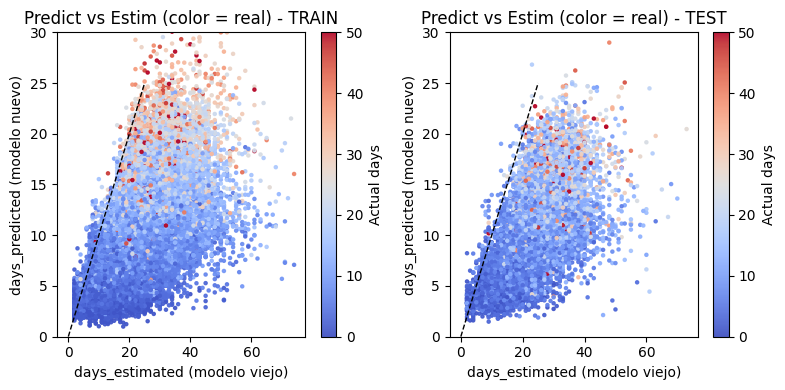

In [69]:
fig, axes = plt.subplots(1, 2, figsize=(8, 4))

sc = axes[0].scatter(y_train['days_estimated'], y_train['days_predicted'], c=y_train['days_to_delivered'],
                     cmap='coolwarm', vmin=0, vmax=50, alpha=0.9, s=5)
plt.colorbar(sc, label='Actual days')
axes[0].plot([0, 25], [0, 25], 'k--', lw=1)
axes[0].set_ylim(0,30)
axes[0].set_xlabel('days_estimated (modelo viejo)')
axes[0].set_ylabel('days_predicted (modelo nuevo)')
axes[0].set_title('Predict vs Estim (color = real) - TRAIN')

sc2 = axes[1].scatter(y_test['days_estimated'], y_test['days_predicted'], c=y_test['days_to_delivered'],
                      cmap='coolwarm', vmin=0, vmax=50, alpha=0.9, s=5)
plt.colorbar(sc2, label='Actual days')
axes[1].plot([0, 25], [0, 25], 'k--', lw=1)
axes[1].set_ylim(0,30)
axes[1].set_xlabel('days_estimated (modelo viejo)')
axes[1].set_ylabel('days_predicted (modelo nuevo)')
axes[1].set_title('Predict vs Estim (color = real) - TEST')
plt.tight_layout()
plt.show()

It is interesting to note that, on the one hand, they have "the same shape" in both train and test... the information obtained during training seems to reproduce well the information in the test dataset (which had not been seen before).

Also note that the diagonal line $x=y$ is where our model coincides with the original (old) estimate. Most points fall below that line, meaning fewer delivery days are predicted than by the old model. Our model therefore improves the estimate; recall that **on average** packages arrived 11 days earlier than the originally estimated date.

Similarly, we can compare our model's average against the average of the actual days (target), the average computed for each value of the old estimate (dataset):

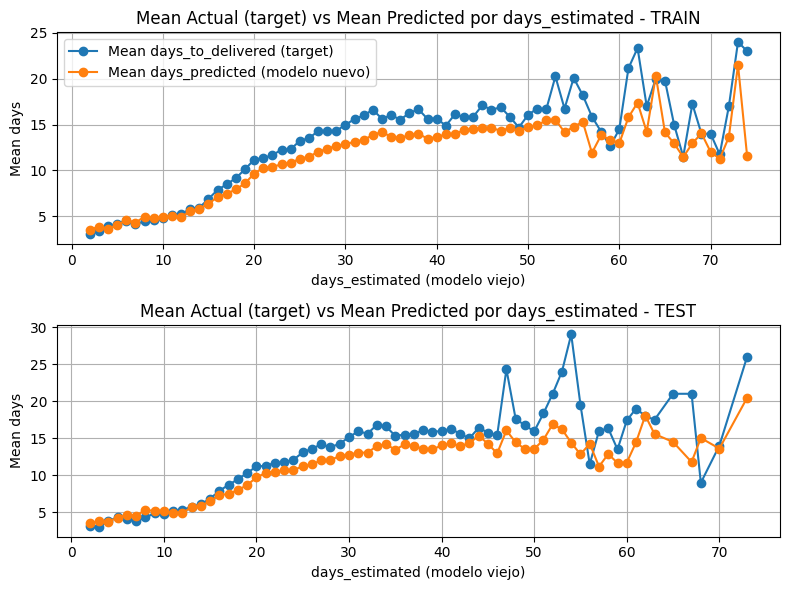

In [70]:
fig, axes = plt.subplots(2, 1, figsize=(8, 6))
agg0 = y_train.groupby('days_estimated').agg(mean_actual=('days_to_delivered','mean'), mean_pred=('days_predicted','mean')).reset_index()
axes[0].plot(agg0['days_estimated'], agg0['mean_actual'], label='Mean days_to_delivered (target)', marker='o')
axes[0].plot(agg0['days_estimated'], agg0['mean_pred'], label='Mean days_predicted (modelo nuevo)', marker='o')
axes[0].set_xlabel('days_estimated (modelo viejo)') ; axes[0].set_ylabel('Mean days')
axes[0].set_title('Mean Actual (target) vs Mean Predicted por days_estimated - TRAIN')
axes[0].legend() ; axes[0].grid(True)

agg1 = y_test.groupby('days_estimated').agg(mean_actual=('days_to_delivered','mean'), mean_pred=('days_predicted','mean')).reset_index()
axes[1].plot(agg1['days_estimated'], agg1['mean_actual'], label='Mean days_to_delivered (target)', marker='o')
axes[1].plot(agg1['days_estimated'], agg1['mean_pred'], label='Mean days_predicted (modelo nuevo)', marker='o')
axes[1].set_xlabel('days_estimated (modelo viejo)') ; axes[1].set_ylabel('Mean days')
axes[1].set_title('Mean Actual (target) vs Mean Predicted por days_estimated - TEST')
axes[1].grid(True) ; plt.tight_layout()
plt.show()

We see that on average our model estimates relatively well, except for the orders catalogued in the dataset with an estimated arrival date greater than ~50 days.
That data range (old estimate above 50 days) was acceptably reproduced in training, but not so much on the test set.

Note that in that range the actual delivery days (the target, blue line) have a lot of variability. If we add the fact that we chose MAE as the metric, it makes sense to find a less precise estimate there (large errors are not paid extra).


Let's compare our model's predictions on the train and test datasets:

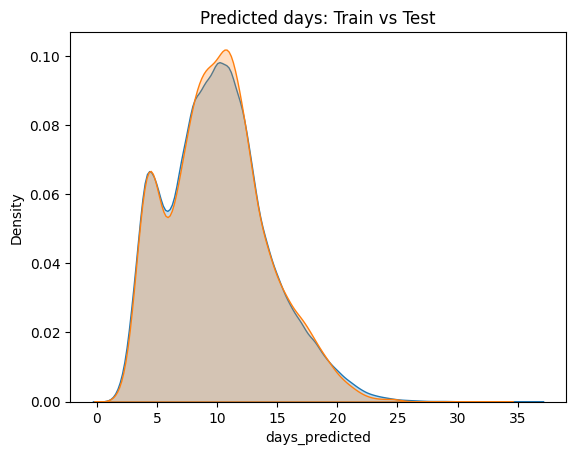

In [71]:
sns.kdeplot(y_train['days_predicted'], label='Train predicted', fill=True)
sns.kdeplot(y_test['days_predicted'], label='Test predicted', fill=True)
plt.title('Predicted days: Train vs Test') ; plt.show()

This plot does not add much, but it shows that the predictions obtained on the test set have a distribution similar to the ones obtained during training. This is expected, since we previously confirmed that the train and test data have similar distributions.

Put another way, `X_train` and `X_test` express the same kind of data, so the same kind of results is obtained in `Y_train` and `Y_test`.

Finally, let's plot the actual values (target) vs our predictions, for both train and test:

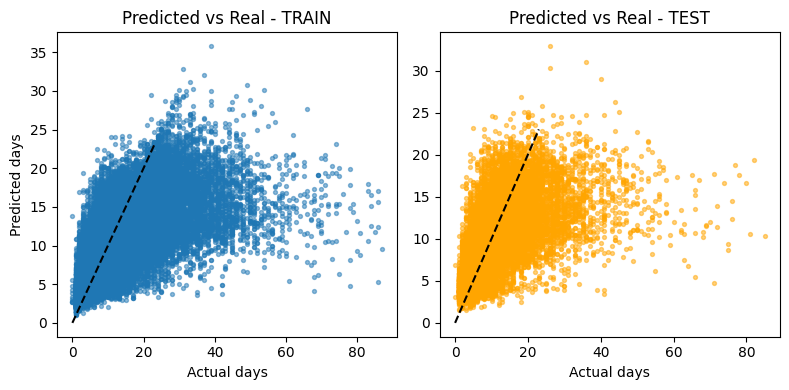

In [72]:
fig, axes = plt.subplots(1, 2, figsize=(8, 4))

axes[0].scatter(y_train['days_to_delivered'], y_train['days_predicted'], s=8, alpha=0.5)
axes[0].plot([0,23],[0,23], 'k--')
axes[0].set_xlabel('Actual days')
axes[0].set_ylabel('Predicted days')
axes[0].set_title('Predicted vs Real - TRAIN')

axes[1].scatter(y_test['days_to_delivered'], y_test['days_predicted'], s=8, alpha=0.5, color='orange')
axes[1].plot([0,23],[0,23], 'k--')
axes[1].set_xlabel('Actual days')
# axes[1].set_ylabel('Predicted days')
axes[1].set_title('Predicted vs Real - TEST')

plt.tight_layout()
plt.show()

Our partial conclusion is that our model struggles to correctly estimate the situations where the delivery takes many days.

But we can also see that the $x=y$ line follows a trend that would seem to match the average of actual days (Actual days).

In [73]:
y_test['days_predicted'].sort_values().head(5)

78718    1.472579
29847    1.589500
18882    1.594938
14151    1.721815
27022    1.763436
Name: days_predicted, dtype: float32

We also observe that our model never predicts values below 1.6 days. What kind of problem is this?

### Interpretation of results. Relevant features.

In [74]:
modelo_final_seleccionado.named_steps

{'preprocessor': ColumnTransformer(transformers=[('num',
                                  Pipeline(steps=[('scaler', StandardScaler())]),
                                  ['price', 'freight_value',
                                   'product_chargeable_weight', 'distance_km',
                                   'sales_same_state']),
                                 ('cat',
                                  Pipeline(steps=[('onehot',
                                                   OneHotEncoder(handle_unknown='ignore'))]),
                                  ['product_sales_volume', 'route'])]),
 'xgb': XGBRegressor(base_score=None, booster=None, callbacks=None,
              colsample_bylevel=None, colsample_bynode=None,
              colsample_bytree=np.float64(0.5926346204785158), device=None,
              early_stopping_rounds=None, enable_categorical=False,
              eval_metric='mae', feature_types=None, feature_weights=None,
              gamma=np.float64(0.398905586068071

How do we evaluate the importance of each variable?

In XGBoost there are several ways to evaluate feature importance through the `feature_importances_` method, such as:

- Weight (or Frequency): Measures the number of times a feature is used to split nodes across all trees of the model. A higher weight indicates more frequent use of that feature in splits.
- Gain: This metric quantifies the average gain (reduction in the loss function) obtained when using a feature to split, across all trees. A higher gain indicates a more significant impact of the feature on model performance.
- Cover: This represents the average coverage of instances in the splits where the feature is used. It considers the number of data points affected by a split involving that feature.

But these three metrics produce very dissimilar results.

This is why we decided to use the SHAP library (SHapley Additive exPlanations).

According to its page:

"SHAP (SHapley Additive exPlanations) is a game theoretic approach to explain the output of any machine learning model. It connects optimal credit allocation with local explanations using the classic Shapley values from game theory and their related extensions."


Below we offer a brief, simple explanation of the SHAP plots we will generate with this library: 

For each model prediction, **SHAP tells us how much each feature pushes the prediction up or down**,
compared to the model's average prediction.

* Positive SHAP value → the feature **increases** the prediction
* Negative SHAP value → the feature **decreases** the prediction
* Absolute value → **strength of the effect**

This works both **per observation** (local explanation) and **on average** (global explanation)

Regarding the plots:

**1. SHAP Summary Plot (Beeswarm)**

Shows the **most important features** (ordered top to bottom)

For each feature:

  * **Each dot = one row of the dataset**
  * Horizontal position = SHAP value (effect on the prediction)
  * Color = feature value (blue = low, red = high)

<u>How to interpret it:</u>

> "the feature placed higher up → is the most influential feature."
>
> "Many red dots to the right →
> large values of the feature tend to **increase** the prediction."
>
> "Blue dots to the left →
> low values of the feature tend to **reduce** the prediction."

<u>Why is it useful?</u>

In a single plot it shows:

* Importance
* Direction of the effect
* Non-linearities
* Interactions

**2. SHAP Bar Plot**

Horizontal bar chart with importances.

Shows the **global importance** of each feature according to the mean |SHAP|.

<u>How to interpret it:</u>

Example:

> "variable_A = 0.12"
> → On average, this feature changes the prediction ±0.12 (in model units).

<u>Why is it useful?</u>

* Simpler than the beeswarm
* Shows only **importance**, not direction
* Ideal for executive reports

**3. SHAP Grouped Importance Plot**

A bar plot that groups the one-hot categories back into a single original variable.

Shows the total contribution of an original variable, even if it has many encoded columns.

<u>Why is it useful?</u>

SHAP allows recovering the real importance of full categorical variables.

In [75]:
import shap

In [76]:
model = modelo_final_seleccionado.named_steps['xgb']
preprocessor = modelo_final_seleccionado.named_steps['preprocessor']
feature_names = preprocessor.get_feature_names_out()
X_train_transformed = preprocessor.transform(X_train)

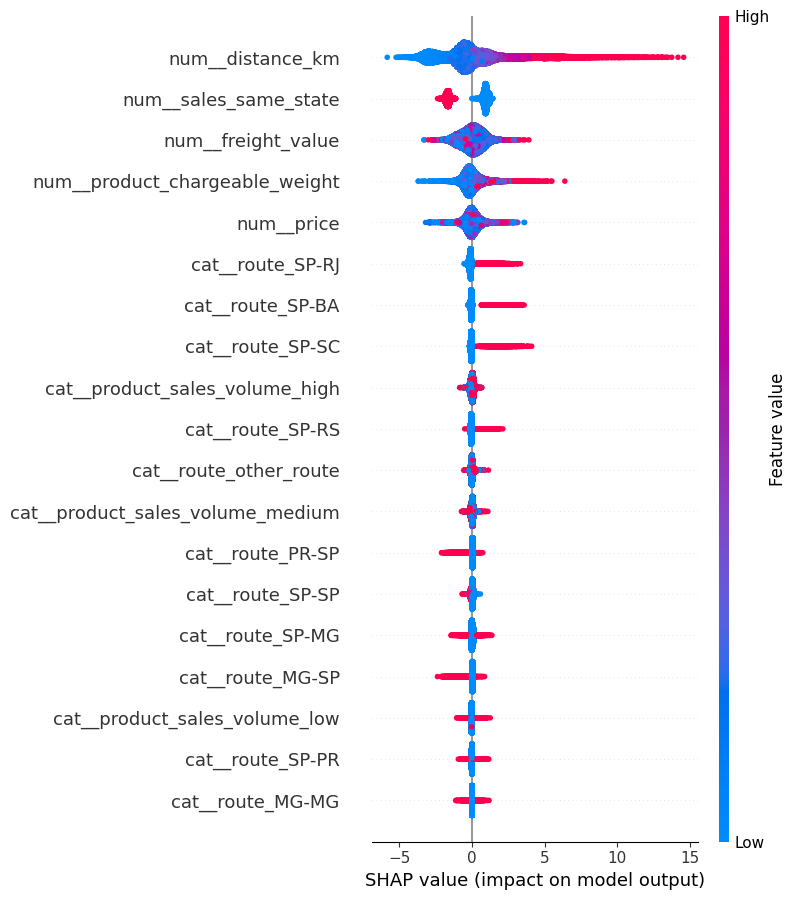

In [77]:
explainer = shap.TreeExplainer(model)
shap_values = explainer.shap_values(X_train_transformed)
shap.summary_plot(shap_values, features=X_train_transformed, feature_names=feature_names)

In [78]:
 # Compute mean absolute SHAP importance
shap_importance = pd.DataFrame({"feature": feature_names, "mean_abs_shap": np.abs(shap_values).mean(axis=0)})
shap_importance_sorted = shap_importance.sort_values("mean_abs_shap", ascending=False)

shap_importance_sorted['percentage'] = 100 * (shap_importance_sorted['mean_abs_shap'] / shap_importance_sorted['mean_abs_shap'].sum())
shap_importance_sorted

,feature,mean_abs_shap,percentage
3,num__distance_km,1.701422,31.830839
4,num__sales_same_state,1.210575,22.647898
1,num__freight_value,0.583257,10.911797
2,num__product_chargeable_weight,0.454873,8.509940
0,num__price,0.363903,6.808034
14,cat__route_SP-RJ,0.214489,4.012749
11,cat__route_SP-BA,0.105447,1.972734
16,cat__route_SP-SC,0.103936,1.944466
5,cat__product_sales_volume_high,0.082554,1.544448
15,cat__route_SP-RS,0.077726,1.454128


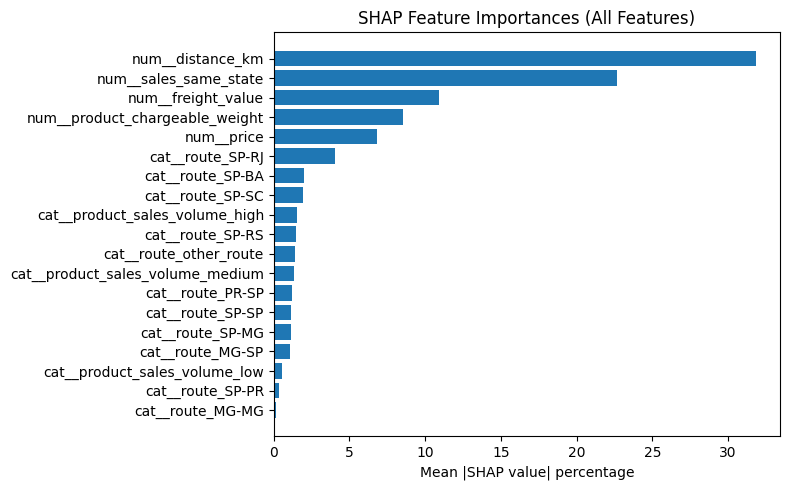

In [79]:
plt.figure(figsize=(8, max(5, len(shap_importance_sorted) * 0.25))) 
plt.barh(shap_importance_sorted["feature"], shap_importance_sorted["percentage"])
plt.gca().invert_yaxis()
plt.xlabel("Mean |SHAP value| percentage") ; plt.title("SHAP Feature Importances (All Features)")
plt.tight_layout() ; plt.show()

We see that the 5 most important features account for 83% of the mean "SHAP" value (global explanation).

These 5 characteristics that explain the target the most are (in order of importance):

* Whether the sale is within the same state (province)
* The distance between seller and buyer
* Freight value
* Effective freight weight (real weight or volumetric weight, whichever is larger)
* Product price

It is worth noting that the variable labelling sales volume as low, medium and high has very low explanatory power. We can therefore consider omitting it if we retrain the model.

In [80]:
# ----------------------------------------------------
#   Extract ORIGINAL variable names
# ----------------------------------------------------
def original_var_name(encoded_name):
    # Split at "__", take second part
    no_prefix = encoded_name.split("__", 1)[1]
    # "rutas_R1" → "route"
    return no_prefix.split("_")[0]

## NOTE: we previously modified the name of num__product_chargeable_weight
## Because otherwise it would merge this variable's importance with that of num__product_sales_volume
shap_importance.iloc[2,0] = 'num__weight_chosen'
# ==============================================
shap_importance["original_var"] = shap_importance["feature"].apply(original_var_name)

shap_grouped = (
    shap_importance.groupby("original_var")["mean_abs_shap"]
    .sum()
    .sort_values(ascending=False)
    .reset_index()
)

shap_grouped['percentage'] = 100 * (shap_grouped['mean_abs_shap'] / shap_grouped['mean_abs_shap'].sum())
shap_grouped

,original_var,mean_abs_shap,percentage
0,distance,1.701422,31.830835
1,sales,1.210575,22.647896
2,route,0.847272,15.851079
3,freight,0.583257,10.911796
4,weight,0.454873,8.509939
5,price,0.363903,6.808033
6,product,0.183897,3.440421


In [81]:
# Rename so the names are more representative
shap_grouped.iloc[0,0] = 'same_state'
shap_grouped.iloc[6,0] = 'product_volume'

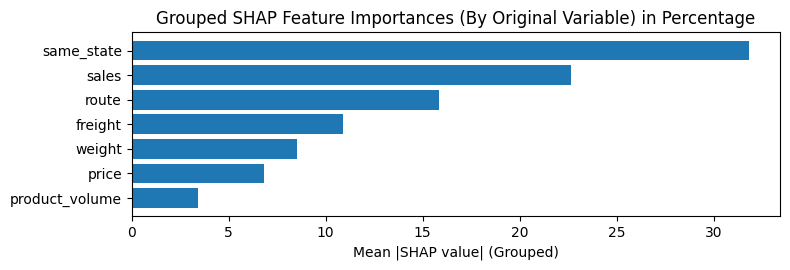

In [82]:
plt.figure(figsize=(8, max(2, len(shap_grouped) * 0.4)))
plt.barh(shap_grouped["original_var"], shap_grouped["percentage"])
plt.gca().invert_yaxis()
plt.xlabel("Mean |SHAP value| (Grouped)") ; plt.title("Grouped SHAP Feature Importances (By Original Variable) in Percentage")
plt.tight_layout() ; plt.show()

In this last plot of importance by original variable, we can see that distance and intra-state sale accumulate 60% of the importance, while the variable labelling sales volume is the least important.

The question arises whether there is some relation between the variable labelling the routes (the 10 with the highest sales volume) and the binary variable identifying intra-state. As we saw before, the state of Sao Paulo accumulates many sellers and many buyers, and perhaps both variables do not measure such dissimilar properties.

So let's see: which routes make up the intra-state sales? that is, those with `sales_same_state=1`

In [83]:
df_final[df_final['sales_same_state']==1]['route'].value_counts()

route
SP-SP          28498
other_route     2298
MG-MG           1468
Name: count, dtype: int64

As we can see, out of the total orders with `sales_same_state=1`, 88 % belong to `route='SP-SP'`.

<u> **Some conclusions:** </u>

- If we retrain the model we can discard the variable that categorizes by sales volume of each product category, `Product_venta`.

- The categorization of routes and of inter/intra-state sales can also be rethought:
  - `sales_same_state` carries importance weight in our model, but so does the SP-SP route, which makes up the vast majority of intra-state sales.
  - In contrast, the routes "other_route" and "MG-MG", which make up the rest of the intra-state sales, seem to have very low importance in the model.
  
  **One option is that, similarly to `product_sales_volume`, we can discard the `route` variable when retraining the model, since `sales_same_state` seems to be sufficient.**
  **Alternatively, it might be enough to differentiate only SP-SP from the rest to obtain similar performance.**
  

### Performance evaluation

We now want to evaluate the model's performance in different situations. For example for each route type (state-state), different freight price ranges, etc.

We first build the already-scaled datasets, so we can evaluate the model directly:

In [84]:
X_train_scaled = modelo_final_seleccionado.named_steps['preprocessor'].transform(X_train)
X_train_scaled = pd.DataFrame(X_train_scaled, columns=feature_names)
X_test_scaled = modelo_final_seleccionado.named_steps['preprocessor'].transform(X_test)
X_test_scaled = pd.DataFrame(X_test_scaled, columns=feature_names)

In [85]:
# Build the same but for the whole dataset
X_total = df_final[numerical_features + categorical_features]
y_total = df_final[target_columns]
y_total['days_predicted']=modelo_final_seleccionado.predict(X_total)

X_total_scaled = modelo_final_seleccionado.named_steps['preprocessor'].transform(X_total)
X_total_scaled = pd.DataFrame(X_total_scaled, columns=feature_names)

#### Variable `route`

As we saw previously, this variable carries some importance in the model (especially some routes), so we expect to see two things here:

- The delivery days (`days_to_delivered`) will change when the value of this variable changes, and our model will reproduce that change. We will see this through the average values for each route.

- It is possible that our model predicts much better for certain values of this variable. We will see this through the MAE computed for each route

In [86]:
routes_by_volume = df_final['route'].value_counts().index.tolist()

In [87]:
df_routes = pd.concat([
    df_final['route'],
    y_total[['days_to_delivered', 'days_estimated', 'days_predicted']]
], axis=1)

In [88]:
score_by_route = pd.DataFrame(columns=['route', 'rmse', 'mae'])
avg_days_by_route = pd.DataFrame(columns=['route', 'days_to_delivered', 'days_estimated', 'days_predicted'])
for route_name in routes_by_volume:
    df_route = df_routes[df_routes['route'] == route_name]
    mae = mean_absolute_error(df_route['days_to_delivered'], df_route['days_predicted'])
    rmse = root_mean_squared_error(df_route['days_to_delivered'], df_route['days_predicted'])
    score_by_route.loc[len(score_by_route)] = [route_name, rmse, mae]

    avg_days_by_route.loc[len(avg_days_by_route)] = [route_name,
                                                               df_route['days_to_delivered'].mean(),
                                                               df_route['days_estimated'].mean(),
                                                               df_route['days_predicted'].mean()]
score_by_route

,route,rmse,mae
0,other_route,7.480250,4.460268
1,SP-SP,4.445995,2.478500
2,SP-RJ,10.196614,5.964442
3,SP-MG,5.569653,3.408496
4,SP-RS,7.739185,4.707898
5,SP-PR,5.943266,3.505887
6,PR-SP,4.760814,2.827204
7,MG-SP,4.965971,2.828996
8,SP-SC,6.826337,4.412770
9,SP-BA,8.507371,5.426714


We see that the lowest MAE values by route occur in MG-MG, SP-SP, PR-SP, MG-SP, SP-MG. Their MAE values are quite a bit lower than the overall level of all the data (~4.4).

They also turn out to have the lowest RMSE values.

MG-MG has a small MAE, even though we saw before that its importance in the model is not relevant. This is because they are few sales, compared to SP-SP.

The remaining purchases within the same state were left out of this first segmentation, and fall under the value "other_route".

- Since MG-MG and SP-SP are the routes with the best performance, we can conclude once again that the `sales_same_state` variable is more relevant for the model than `route`.

- Recall also that when computing the importance by grouped original variable, `sales_same_state` remained more important than `route`.

Finally, let's plot the average days for each route:

In [89]:
routes_by_mae = score_by_route.sort_values('mae', ascending=True)['route'].tolist()
routes_by_mae

['MG-MG',
 'SP-SP',
 'PR-SP',
 'MG-SP',
 'SP-MG',
 'SP-PR',
 'SP-SC',
 'other_route',
 'SP-RS',
 'SP-BA',
 'SP-RJ']

In [90]:
maes = score_by_route.sort_values('mae', ascending=True)['mae'].round(2).tolist()
maes

[2.15, 2.48, 2.83, 2.83, 3.41, 3.51, 4.41, 4.46, 4.71, 5.43, 5.96]

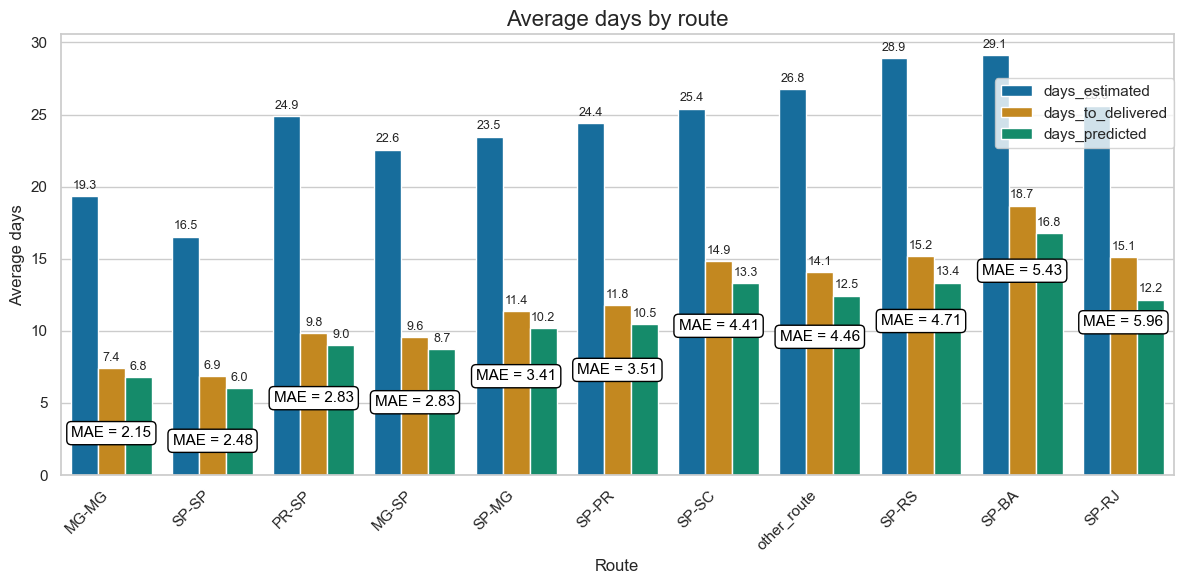

In [91]:
# Reshape the data to long format for Seaborn
df_melted = avg_days_by_route.melt(
    id_vars='route',
    value_vars=['days_estimated', 'days_to_delivered', 'days_predicted'],
    var_name='Series',
    value_name='Average days')

sns.set(style='whitegrid', palette='colorblind')
plt.figure(figsize=(12, 6))
ax = sns.barplot(data=df_melted, x='route', y='Average days', hue='Series', order=routes_by_mae) #order=routes_by_volume)

# --- Add boxes with the different MAE values per group ---
mae_values = maes

# Get the positions of each group (centers on the x axis)
group_positions = ax.get_xticks()

for pos, mae in zip(group_positions, mae_values):
    # Get the bars close to that position
    group_bars = [bar for bar in ax.patches if abs(bar.get_x() + bar.get_width()/2 - pos) < 0.2]
    if group_bars:
        y_max = max(bar.get_height() for bar in group_bars)
        ax.text(
            pos, y_max -5,  # adjust "+1" according to the y-axis scale
            f'MAE = {mae:.2f}',
            ha='center', va='bottom',
            fontsize=11, color='black',
            bbox=dict(facecolor='white', edgecolor='black', boxstyle='round,pad=0.3')
        )

# Value labels above each bar
for container in ax.containers:
    ax.bar_label(container, fmt='%.1f', padding=3, fontsize=9)

plt.title('Average days by route', fontsize=16)
plt.xlabel('Route', fontsize=12) ; plt.xticks(rotation=45, ha='right') ; plt.ylabel('Average days', fontsize=12)
plt.legend(bbox_to_anchor=(1, 0.9), loc='upper right', borderaxespad=0.)
plt.tight_layout() ; plt.show()


We see that, at least on average, the variability of the target is explained by the `route` feature.

#### Variable `product_sales_volume`

As we saw before, the 3 values of this variable are among the 5 least important features of the model.

Doing an analysis similar to the one for `route`, we can then expect the following:

- It will not explain the target's variability, so the average of `days_to_delivered` will be similar for the three values of `product_sales_volume`.

- We might also expect the MAE for the data of these 3 categories not to differ among themselves.

In [92]:
df_volume = pd.concat([
    df_final['product_sales_volume'],
    y_total[['days_to_delivered', 'days_estimated', 'days_predicted']]
], axis=1)

In [93]:
score_by_volume = pd.DataFrame(columns=['product_sales_volume', 'rmse', 'mae'])
avg_days_by_volume = pd.DataFrame(columns=['product_sales_volume', 'days_to_delivered', 'days_estimated', 'days_predicted'])
for vol in ['low','medium','high']:
    df_nivel = df_volume[df_volume['product_sales_volume'] == vol]
    mae = mean_absolute_error(df_nivel['days_to_delivered'], df_nivel['days_predicted'])
    rmse = root_mean_squared_error(df_nivel['days_to_delivered'], df_nivel['days_predicted'])
    score_by_volume.loc[len(score_by_volume)] = [vol, rmse, mae]

    avg_days_by_volume.loc[len(avg_days_by_volume)] = [vol,
                                                           df_nivel['days_to_delivered'].mean(),
                                                           df_nivel['days_estimated'].mean(),
                                                           df_nivel['days_predicted'].mean()]
score_by_volume

,product_sales_volume,rmse,mae
0,low,6.166199,3.447062
1,medium,6.594235,3.724533
2,high,6.687503,3.808733


We see that the MAE does not change considerably across the different values of the `product_sales_volume` variable

In [94]:
maes = score_by_volume.sort_values('mae', ascending=True)['mae'].round(2).tolist()
maes

[3.45, 3.72, 3.81]

Plotting mean day values:

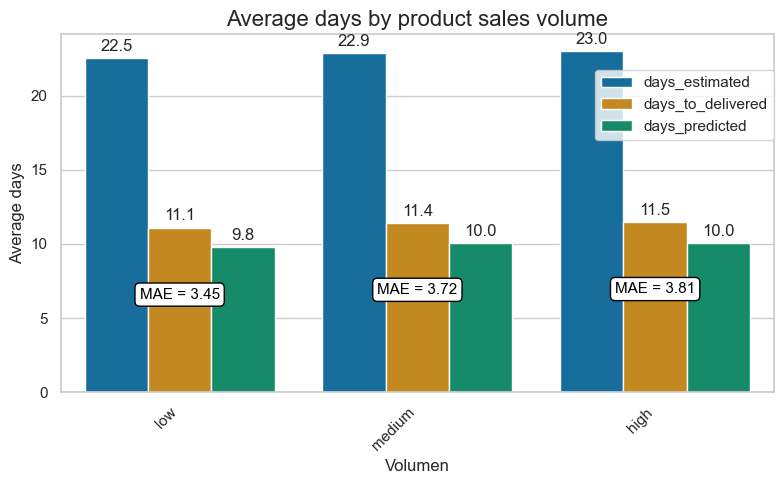

In [95]:
# Reshape the data to long format for Seaborn
df_melted = avg_days_by_volume.melt(
    id_vars='product_sales_volume',
    value_vars=['days_estimated', 'days_to_delivered', 'days_predicted'],
    var_name='Series',
    value_name='Average days')

sns.set(style='whitegrid', palette='colorblind')
plt.figure(figsize=(8, 5))
ax = sns.barplot(data=df_melted, x='product_sales_volume', y='Average days', hue='Series')

# --- Add boxes with the different MAE values per group ---
mae_values = maes

# Get the positions of each group (centers on the x axis)
group_positions = ax.get_xticks()

for pos, mae in zip(group_positions, mae_values):
    # Get the bars close to that position
    group_bars = [bar for bar in ax.patches if abs(bar.get_x() + bar.get_width()/2 - pos) < 0.2]
    if group_bars:
        y_max = max(bar.get_height() for bar in group_bars)
        ax.text(
            pos, y_max -5,  # adjust "+1" according to the y-axis scale
            f'MAE = {mae:.2f}',
            ha='center', va='bottom',
            fontsize=11, color='black',
            bbox=dict(facecolor='white', edgecolor='black', boxstyle='round,pad=0.3')
        )

# Value labels above each bar
for container in ax.containers:
    ax.bar_label(container, fmt='%.1f', padding=3, fontsize=12)

plt.title('Average days by product sales volume', fontsize=16)
plt.xlabel('Volumen', fontsize=12) ; plt.xticks(rotation=45, ha='right') ; plt.ylabel('Average days', fontsize=12)
plt.legend(bbox_to_anchor=(1, 0.9), loc='upper right', borderaxespad=0.)
plt.tight_layout() ; plt.show()

Here we can confirm once again that this variable is not explanatory.

#### Variable `sales_same_state`

This is the most important variable.

In [96]:
df_same_state = pd.concat([
    df_final['sales_same_state'],
    y_total[['days_to_delivered', 'days_estimated', 'days_predicted']]
], axis=1)

In [97]:
score_same_state = pd.DataFrame(columns=['same_state', 'rmse', 'mae'])
avg_days_by_state_flag = pd.DataFrame(columns=['sales_same_state', 'days_to_delivered', 'days_estimated', 'days_predicted'])
for same in [1,0]:
    df_nivel = df_same_state[df_same_state['sales_same_state'] == same]
    mae = mean_absolute_error(df_nivel['days_to_delivered'], df_nivel['days_predicted'])
    rmse = root_mean_squared_error(df_nivel['days_to_delivered'], df_nivel['days_predicted'])
    score_same_state.loc[len(score_same_state)] = [same, rmse, mae]

    avg_days_by_state_flag.loc[len(avg_days_by_state_flag)] = [same,
                                                                   df_nivel['days_to_delivered'].mean(),
                                                                   df_nivel['days_estimated'].mean(),
                                                                   df_nivel['days_predicted'].mean()]
score_same_state

,same_state,rmse,mae
0,1.0,4.419645,2.446404
1,0.0,7.564034,4.473725


We see that the MAE is considerably reduced for the orders where seller and buyer are from the same state.

In [98]:
maes = score_same_state.sort_values('mae', ascending=True)['mae'].round(2).tolist()
maes

[2.45, 4.47]

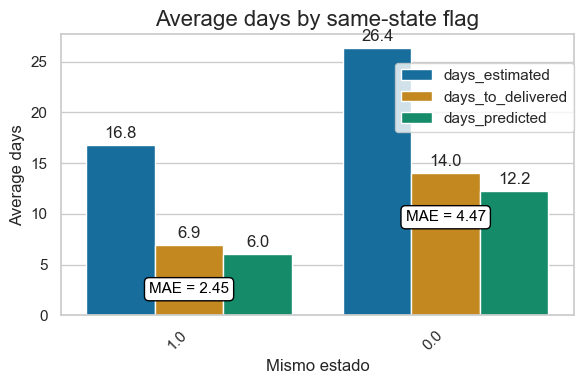

In [99]:
df_melted = avg_days_by_state_flag.melt(
    id_vars='sales_same_state',
    value_vars=['days_estimated', 'days_to_delivered', 'days_predicted'],
    var_name='Series',
    value_name='Average days')

sns.set(style='whitegrid', palette='colorblind')
plt.figure(figsize=(6, 4))
ax = sns.barplot(data=df_melted, x='sales_same_state', y='Average days', hue='Series', order=[1.,0.])

for container in ax.containers:
    ax.bar_label(container, fmt='%.1f', padding=3, fontsize=12)

# --- Add boxes with the different MAE values per group ---
mae_values = maes  # one value per group, in the same order as 'order'

# Get the positions of each group (centers on the x axis)
group_positions = ax.get_xticks()

for pos, mae in zip(group_positions, mae_values):
    # Get the bars close to that position
    group_bars = [bar for bar in ax.patches if abs(bar.get_x() + bar.get_width()/2 - pos) < 0.2]
    if group_bars:
        y_max = max(bar.get_height() for bar in group_bars)
        ax.text(
            pos, y_max -5,  # adjust "+1" according to the y-axis scale
            f'MAE = {mae:.2f}',
            ha='center', va='bottom',
            fontsize=11, color='black',
            bbox=dict(facecolor='white', edgecolor='black', boxstyle='round,pad=0.3')
        )

plt.title('Average days by same-state flag', fontsize=16)
plt.xlabel('Mismo estado', fontsize=12) ; plt.xticks(rotation=45, ha='right') ; plt.ylabel('Average days', fontsize=12)
plt.legend(bbox_to_anchor=(1, 0.9), loc='upper right', borderaxespad=0.)
plt.tight_layout() ; plt.show()

#### Variable `distance_km`

This variable is also very important.

Being a continuous variable, we can split it into bands and see how the prediction average behaves in each of them.

In [100]:
df_distance = pd.concat([
    df_final['distance_km'],
    y_total[['days_to_delivered', 'days_estimated', 'days_predicted']]
], axis=1)

In [101]:
# Define the bands
max_val = df_distance['distance_km'].max()
bins = [0, 250, 500, 750, 1000, max_val]
labels = ['0–250 km', '251–500 km', '501–750 km', '751–1000 km', f'1001–{int(max_val)} km']
# Create the categorical band variable
df_distance['distance_range'] = pd.cut(df_distance['distance_km'], bins=bins, labels=labels, include_lowest=True)

In [102]:
score_by_distance = pd.DataFrame(columns=['distance', 'rmse', 'mae'])
avg_days_by_distance = pd.DataFrame(columns=['distance', 'days_to_delivered', 'days_estimated', 'days_predicted'])
for range in labels:
    df_nivel = df_distance[df_distance['distance_range'] == range]
    mae = mean_absolute_error(df_nivel['days_to_delivered'], df_nivel['days_predicted'])
    rmse = root_mean_squared_error(df_nivel['days_to_delivered'], df_nivel['days_predicted'])
    score_by_distance.loc[len(score_by_distance)] = [range, rmse, mae]

    avg_days_by_distance.loc[len(avg_days_by_distance)] = [range,
                                                               df_nivel['days_to_delivered'].mean(),
                                                               df_nivel['days_estimated'].mean(),
                                                               df_nivel['days_predicted'].mean()]
score_by_distance

,distance,rmse,mae
0,0–250 km,4.373614,2.375354
1,251–500 km,6.718131,3.794100
2,501–750 km,7.168527,4.189029
3,751–1000 km,7.138682,4.337826
4,1001–3384 km,8.491475,5.243578


In [103]:
maes = score_by_distance['mae'].round(2).to_list()
maes

[2.38, 3.79, 4.19, 4.34, 5.24]

The lowest MAE belongs to the orders that travel less than 250 km (which is consistent with the orders that move within the same state/province).

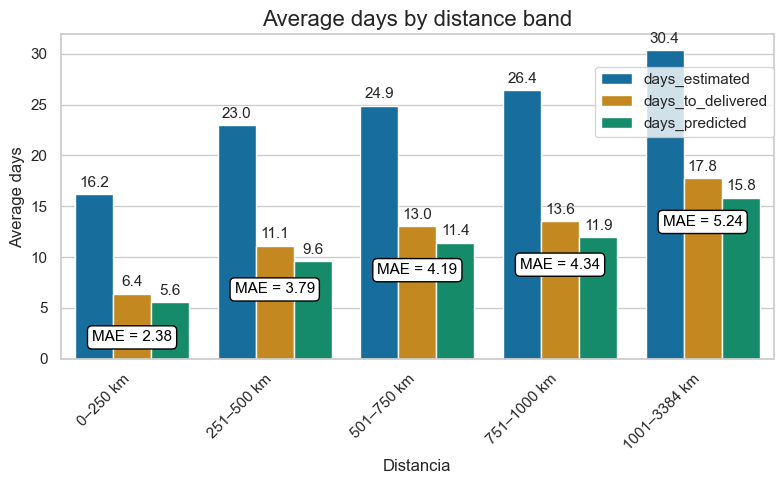

In [104]:
df_melted = avg_days_by_distance.melt(
    id_vars='distance',
    value_vars=['days_estimated', 'days_to_delivered', 'days_predicted'],
    var_name='Series',
    value_name='Average days')

sns.set(style='whitegrid', palette='colorblind')
plt.figure(figsize=(8, 5))
ax = sns.barplot(data=df_melted, x='distance', y='Average days', hue='Series')

for container in ax.containers:
    ax.bar_label(container, fmt='%.1f', padding=3, fontsize=11)

# --- Add boxes with the different MAE values per group ---
mae_values = maes  # one value per group, in the same order as 'order'

# Get the positions of each group (centers on the x axis)
group_positions = ax.get_xticks()

for pos, mae in zip(group_positions, mae_values):
    # Get the bars close to that position
    group_bars = [bar for bar in ax.patches if abs(bar.get_x() + bar.get_width()/2 - pos) < 0.2]
    if group_bars:
        y_max = max(bar.get_height() for bar in group_bars)
        ax.text(
            pos, y_max -5,  # adjust "+1" according to the y-axis scale
            f'MAE = {mae:.2f}',
            ha='center', va='bottom',
            fontsize=11, color='black',
            bbox=dict(facecolor='white', edgecolor='black', boxstyle='round,pad=0.3')
        )

plt.title('Average days by distance band', fontsize=16)
plt.xlabel('Distancia', fontsize=12) ; plt.xticks(rotation=45, ha='right') ; plt.ylabel('Average days', fontsize=12)
plt.legend(bbox_to_anchor=(1, 0.9), loc='upper right', borderaxespad=0.)
plt.tight_layout() ; plt.show()

#### Freight price variable `freight_value`

We will do something similar to the `distance_km` grouping, but splitting into quartiles.

In [105]:
df_freight = pd.concat([
    df_final['freight_value'],
    y_total[['days_estimated', 'days_to_delivered', 'days_predicted']]
], axis=1)

In [106]:
# define the quartiles
quartiles = df_freight['freight_value'].quantile([0, 0.25, 0.5, 0.75, 1.0]).values

# Create descriptive labels with the rounded limits
labels = [
    f'Q1: {quartiles[0]:.0f}–{quartiles[1]:.0f}',
    f'Q2: {quartiles[1]:.0f}–{quartiles[2]:.0f}',
    f'Q3: {quartiles[2]:.0f}–{quartiles[3]:.0f}',
    f'Q4: {quartiles[3]:.0f}–{quartiles[4]:.0f}'
]

# Discretize the variable into quartiles
df_freight['freight_quartile'] = pd.cut(df_freight['freight_value'], bins=quartiles, labels=labels, include_lowest=True)


In [107]:
score_by_freight = pd.DataFrame(columns=['freight_q', 'rmse', 'mae'])
avg_days_by_freight = pd.DataFrame(columns=['freight_q', 'days_to_delivered', 'days_estimated', 'days_predicted'])
for quart in labels:
    df_nivel = df_freight[df_freight['freight_quartile'] == quart]
    mae = mean_absolute_error(df_nivel['days_to_delivered'], df_nivel['days_predicted'])
    rmse = root_mean_squared_error(df_nivel['days_to_delivered'], df_nivel['days_predicted'])
    score_by_freight.loc[len(score_by_freight)] = [quart, rmse, mae]

    avg_days_by_freight.loc[len(avg_days_by_freight)] = [quart,
                                                         df_nivel['days_to_delivered'].mean(),
                                                         df_nivel['days_estimated'].mean(),
                                                         df_nivel['days_predicted'].mean()]
score_by_freight

,freight_q,rmse,mae
0,Q1: 0–14,4.571889,2.476314
1,Q2: 14–17,6.950898,4.008104
2,Q3: 17–24,7.264933,4.275685
3,Q4: 24–503,7.275530,4.233359


Our model predicts very well for the freight prices located in the first quartile.

- On the one hand, it makes sense to identify the orders with the lowest freight prices with the ones that take fewer days to deliver, travel shorter distances and stay within the same state.

- And on the other hand, all those characteristics are the ones for which we have seen our model performs best. Therefore the lowest freight prices also belong to the subgroup our model predicts best.

In [108]:
maes = score_by_freight['mae'].round(2).to_list()
maes

[2.48, 4.01, 4.28, 4.23]

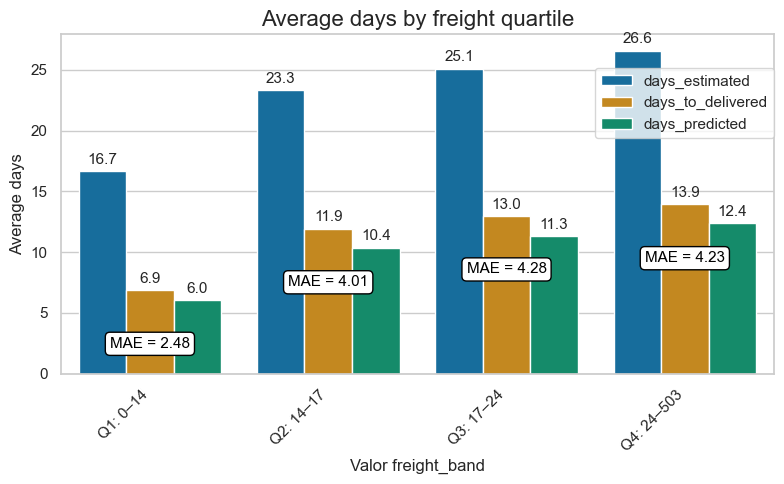

In [109]:
df_melted = avg_days_by_freight.melt(
    id_vars='freight_q',
    value_vars=['days_estimated', 'days_to_delivered', 'days_predicted'],
    var_name='Series',
    value_name='Average days')

sns.set(style='whitegrid', palette='colorblind')
plt.figure(figsize=(8, 5))
ax = sns.barplot(data=df_melted, x='freight_q', y='Average days', hue='Series', order=labels)

for container in ax.containers:
    ax.bar_label(container, fmt='%.1f', padding=3, fontsize=11)


# --- Add boxes with the different MAE values per group ---
mae_values = maes  # one value per group, in the same order as 'order'

# Get the positions of each group (centers on the x axis)
group_positions = ax.get_xticks()

for pos, mae in zip(group_positions, mae_values):
    # Get the bars close to that position
    group_bars = [bar for bar in ax.patches if abs(bar.get_x() + bar.get_width()/2 - pos) < 0.2]
    if group_bars:
        y_max = max(bar.get_height() for bar in group_bars)
        ax.text(
            pos, y_max -5,  # adjust "+1" according to the y-axis scale
            f'MAE = {mae:.2f}',
            ha='center', va='bottom',
            fontsize=11, color='black',
            bbox=dict(facecolor='white', edgecolor='black', boxstyle='round,pad=0.3')
        )

plt.title('Average days by freight quartile', fontsize=16)
plt.xlabel('Valor freight_band', fontsize=12) ; plt.xticks(rotation=45, ha='right') ; plt.ylabel('Average days', fontsize=12)
plt.legend(bbox_to_anchor=(1, 0.9), loc='upper right', borderaxespad=0.)
plt.tight_layout() ; plt.show()

### Conclusions and future steps

#### Conclusion

To conclude and summarize the work done, we determined that, based on the improvement opportunity initially posed (improvement in the delivery days estimate), the model with the best performance is XGBoost.

After analyzing the importance and performance of each model variable, we can conclude that:

- The actual delivery days are estimated more precisely using the following variables:
  - Distance in km between buyer and seller
  - Purchase orders within the same state
  - Freight value
  - Buyer-seller route (lower incidence, since it correlates with the second variable named)

#### Future improvements

- Incorporate the reviews data:
  
  We can analyze whether the ratings given by buyers relate to the delivery times. If affirmative, past review values are relevant for building a seller segmentation.
  
  This can also be combined with the number of days the seller takes to dispatch the product, in order to define a seller "score" variable.


- Narrow the temporal range of the analysis:

  To improve the effectiveness of the estimated days, we could restrict the training data time range to 2018, when the sales volume was higher and stable, and when the original delivery estimate was more precise.